# DDM501 - AI in Production: Course Capstone Project
## Notebook 01: Deep Exploratory Data Analysis (EDA) & Feature Engineering
**Domain**: E-Commerce & Retail | **Topic**: Real-Time Product Recommendation System
**Dataset**: Combined Amazon Cell Phones & Accessories + Electronics Datasets

---

In [1]:
import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix

from src.data.loader import load_raw_reviews, load_raw_meta
from src.data.preprocessor import DataPreprocessor

%matplotlib inline
sns.set_theme(style='darkgrid')
plt.rcParams['font.size'] = 11

### 1. Data Ingestion & Multi-Dataset Merging

In [2]:
reviews_paths = [
    '../dataset/Cell_Phones_and_Accessories_5.json',
    '../dataset/Electronics_5.json'
]
meta_paths = [
    '../dataset/meta_Cell_Phones_and_Accessories.json',
    '../dataset/meta_Electronics.json'
]

# Load reviews and metadata
df_reviews = load_raw_reviews(reviews_paths, limit=100000)
df_meta = load_raw_meta(meta_paths, limit=100000)

print(f"Total Loaded Reviews: {len(df_reviews):,}")
print(f"Total Unique Products in Metadata: {len(df_meta):,}")
df_reviews.head()

Total Loaded Reviews: 100,000
Total Unique Products in Metadata: 100,000


,reviewerID,asin,overall,unixReviewTime,summary,reviewText
0,A30TL5EWN6DFXT,120401325X,4.0,1400630400,Looks Good,They look good and stick good! I just don't li...
1,ASY55RVNIL0UD,120401325X,5.0,1389657600,Really great product.,These stickers work like the review says they ...
2,A2TMXE2AFO7ONB,120401325X,5.0,1403740800,LOVE LOVE LOVE,These are awesome and make my phone look so st...
3,AWJ0WZQYMYFQ4,120401325X,4.0,1382313600,Cute!,Item arrived in great time and was in perfect ...
4,ATX7CZYFXI1KW,120401325X,5.0,1359849600,leopard home button sticker for iphone 4s,"awesome! stays on, and looks great. can be use..."


### 2. Matrix Sparsity & Interaction Density Analysis
In recommendation systems, **sparsity** measures the percentage of missing user-item interaction pairs in the rating matrix $R \in \mathbb{R}^{|U| \times |I|}$.
$$\text{Density} = \frac{|E|}{|U| \times |I|} \times 100\%, \quad \text{Sparsity} = 100\% - \text{Density}$$

In [3]:
num_users = df_reviews['reviewerID'].nunique()
num_items = df_reviews['asin'].nunique()
num_interactions = len(df_reviews)
total_cells = num_users * num_items
density_pct = (num_interactions / total_cells) * 100
sparsity_pct = 100.0 - density_pct

print("=" * 60)
print("               DATASET MATRIX SPARSITY STATS               ")
print("=" * 60)
print(f"- Total Unique Users (|U|):          {num_users:,}")
print(f"- Total Unique Items (|I|):          {num_items:,}")
print(f"- Total Non-Zero Ratings (|E|):      {num_interactions:,}")
print(f"- Total Matrix Grid Size (|U| x |I|): {total_cells:,}")
print(f"- Interaction Density Ratio:         {density_pct:.4f}%")
print(f"- Matrix Sparsity Ratio:            {sparsity_pct:.4f}%")
print("=" * 60)

               DATASET MATRIX SPARSITY STATS               
- Total Unique Users (|U|):          25,748
- Total Unique Items (|I|):          5,323
- Total Non-Zero Ratings (|E|):      100,000
- Total Matrix Grid Size (|U| x |I|): 137,056,604
- Interaction Density Ratio:         0.0730%
- Matrix Sparsity Ratio:            99.9270%


### 3. Cold Start & Long-Tail Distribution Analysis
Evaluating the ratio of **Cold-Start users** (users with only 1 rating) and **Cold-Start items** (rare items with only 1 interaction).

Cold-Start Users (Only 1 Rating): 3,425 (13.30% of users)
Cold-Start Items (Only 1 Review): 0 (0.00% of items)


C:\Users\Admin\AppData\Local\Temp\ipykernel_9292\3081496359.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=user_tiers, palette='mako')


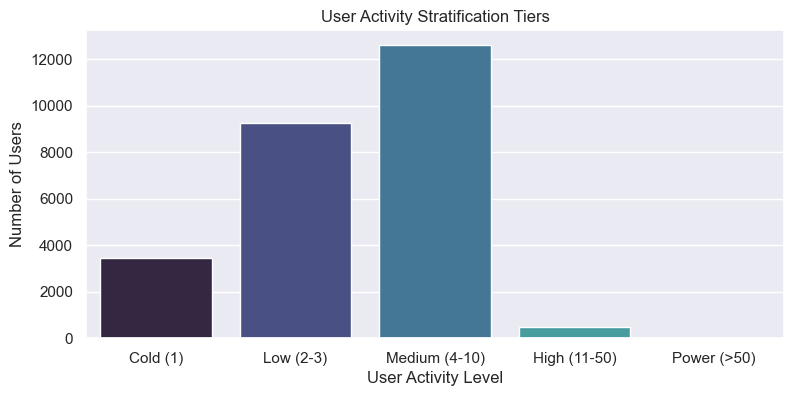

In [4]:
user_counts = df_reviews['reviewerID'].value_counts()
item_counts = df_reviews['asin'].value_counts()

cold_users = (user_counts == 1).sum()
cold_items = (item_counts == 1).sum()

print(f"Cold-Start Users (Only 1 Rating): {cold_users:,} ({cold_users/num_users*100:.2f}% of users)")
print(f"Cold-Start Items (Only 1 Review): {cold_items:,} ({cold_items/num_items*100:.2f}% of items)")

# User Activity Tiering
user_tiers = pd.cut(user_counts, bins=[0, 1, 3, 10, 50, np.inf], labels=['Cold (1)', 'Low (2-3)', 'Medium (4-10)', 'High (11-50)', 'Power (>50)'])
plt.figure(figsize=(9, 4))
sns.countplot(x=user_tiers, palette='mako')
plt.title('User Activity Stratification Tiers')
plt.xlabel('User Activity Level')
plt.ylabel('Number of Users')
plt.show()

### 4. Item Popularity Lorenz Curve & Gini Coefficient
The **Gini Coefficient** measures popularity bias in recommendation systems. High Gini (> 0.7) means a tiny fraction of popular items receive almost all user interactions.

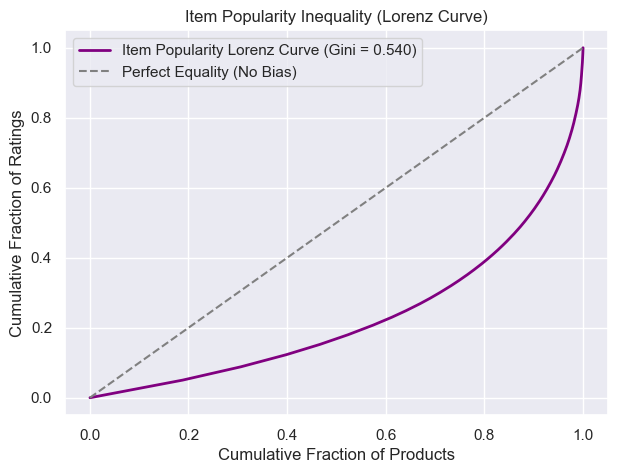

In [5]:
sorted_counts = np.sort(item_counts.values)
n = len(sorted_counts)
index = np.arange(1, n + 1)
gini_coef = (2 * np.sum(index * sorted_counts)) / (n * np.sum(sorted_counts)) - (n + 1) / n

# Lorenz Curve Plot
cum_interactions = np.cumsum(sorted_counts) / np.sum(sorted_counts)
cum_items = np.arange(1, n + 1) / n

plt.figure(figsize=(7, 5))
plt.plot(cum_items, cum_interactions, label=f'Item Popularity Lorenz Curve (Gini = {gini_coef:.3f})', color='purple', lw=2)
plt.plot([0, 1], [0, 1], '--', label='Perfect Equality (No Bias)', color='gray')
plt.title('Item Popularity Inequality (Lorenz Curve)')
plt.xlabel('Cumulative Fraction of Products')
plt.ylabel('Cumulative Fraction of Ratings')
plt.legend()
plt.show()

### 5. Rating Score Bias & Class Imbalance Analysis

C:\Users\Admin\AppData\Local\Temp\ipykernel_9292\1089037140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='overall', data=df_reviews, ax=axes[0], palette='crest')
C:\Users\Admin\AppData\Local\Temp\ipykernel_9292\1089037140.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df_meta_top_cat, ax=axes[1], palette='rocket')


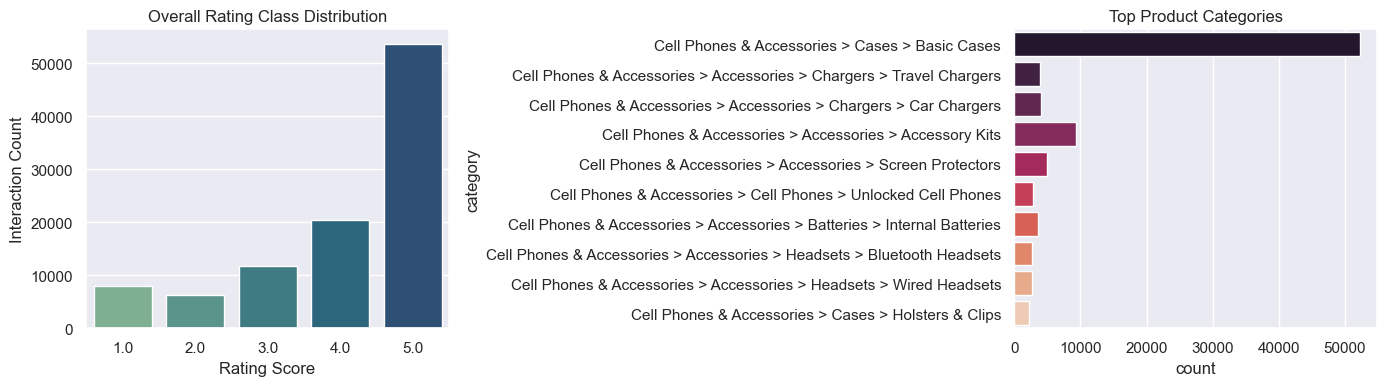

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(x='overall', data=df_reviews, ax=axes[0], palette='crest')
axes[0].set_title('Overall Rating Class Distribution')
axes[0].set_xlabel('Rating Score')
axes[0].set_ylabel('Interaction Count')

# Average Rating per Category (Top 10)
cat_summary = df_meta.groupby('category').size().nlargest(10).index
df_meta_top_cat = df_meta[df_meta['category'].isin(cat_summary)]
sns.countplot(y='category', data=df_meta_top_cat, ax=axes[1], palette='rocket')
axes[1].set_title('Top Product Categories')
plt.tight_layout()
plt.show()

### 6. Feature Engineering & Preprocessing Execution
- **Bayesian Average Rating Calculation**: Adjusts product mean rating by penalizing items with very few reviews.
$$WR = \frac{v}{v+m} R + \frac{m}{v+m} C$$
where $v$ is review count, $m$ is minimum threshold, $R$ is item mean rating, and $C$ is overall mean rating across catalog.
- **$K$-Core Filtering**: Filter sparse interactions below minimum thresholds ($min\_user\_ratings=2, min\_item\_ratings=2$).
- **Dense Index Mapping**: Convert string IDs (`reviewerID`, `asin`) to 0-indexed integers (`user_idx`, `item_idx`).

In [7]:
prep = DataPreprocessor(min_user_ratings=2, min_item_ratings=2)
train_df, test_df = prep.fit_transform(df_reviews, df_meta)

print("=" * 60)
print("          PREPROCESSING & FEATURE ENGINEERING RESULTS          ")
print("=" * 60)
print(f"- Preprocessed Train interactions: {len(train_df):,}")
print(f"- Preprocessed Test interactions:  {len(test_df):,}")
print(f"- Number of Unique Mapped Users:   {prep.num_users:,}")
print(f"- Number of Unique Mapped Items:   {prep.num_items:,}")
print(f"- Top Bayesian Popular Items:     {prep.popular_items[:5]}")
print("=" * 60)

train_df[['reviewerID', 'asin', 'user_idx', 'item_idx', 'overall']].head()

          PREPROCESSING & FEATURE ENGINEERING RESULTS          
- Preprocessed Train interactions: 77,260
- Preprocessed Test interactions:  19,315
- Number of Unique Mapped Users:   22,323
- Number of Unique Mapped Items:   5,323
- Top Bayesian Popular Items:     ['B006EEIBWU', 'B0025V3GCG', 'B004DE0GZS', 'B005EEO4OA', 'B005LBEA6I']


,reviewerID,asin,user_idx,item_idx,overall
46746,A3JN3XG1IQAPBR,B0054U6CEE,17908,2703,5.0
57474,A3HSZHJ3IGN6Q3,B005NF0B8I,17186,3207,4.0
3649,A2S14VSL1V6K76,B000S5Q9CA,2839,249,5.0
47456,A6GRQDFHIOFL6,B00563TSU4,10418,2748,5.0
42487,ACF9QHVMG6FZ5,B004WIQW3U,17176,2414,5.0
